In [1]:
import sys; sys.path.append("..")
import numpy as np
import pandas as pd
import joblib
import warnings; warnings.filterwarnings("ignore")
from models.models import (train_regression_models, evaluate_regression,
                         train_classification_models, evaluate_classification,
                         save_model)
from src.visualization import plot_feature_importance, plot_confusion_matrix, plot_actual_vs_predicted

(X_train, X_test, X_train_sc, X_test_sc,
 y_train_r, y_test_r, y_train_c, y_test_c,
 feature_names) = joblib.load("../data/processed/splits.pkl")

In [2]:
print("REGRESIÓN — Predicción de log(Streams)")
reg_models = train_regression_models(X_train, y_train_r)

REGRESIÓN — Predicción de log(Streams)
Ridge entrenado
RandomForest entrenado
XGBoost entrenado


In [3]:
reg_results = evaluate_regression(reg_models, X_test, y_test_r)
print("\n=== Resultados Regresión ===")
print(reg_results.to_string(index=False))


=== Resultados Regresión ===
      Modelo     R²   RMSE    MAE
RandomForest 0.5445 1.0856 0.8005
     XGBoost 0.5040 1.1330 0.8484
       Ridge 0.4090 1.2366 0.9607


In [4]:

best_reg_name = reg_results.iloc[0]["Modelo"]
best_reg = reg_models[best_reg_name]
save_model(best_reg, f"best_regressor_{best_reg_name}")
print(f"\nMejor modelo regresión: {best_reg_name}")

Modelo guardado: models/best_regressor_RandomForest.pkl

Mejor modelo regresión: RandomForest


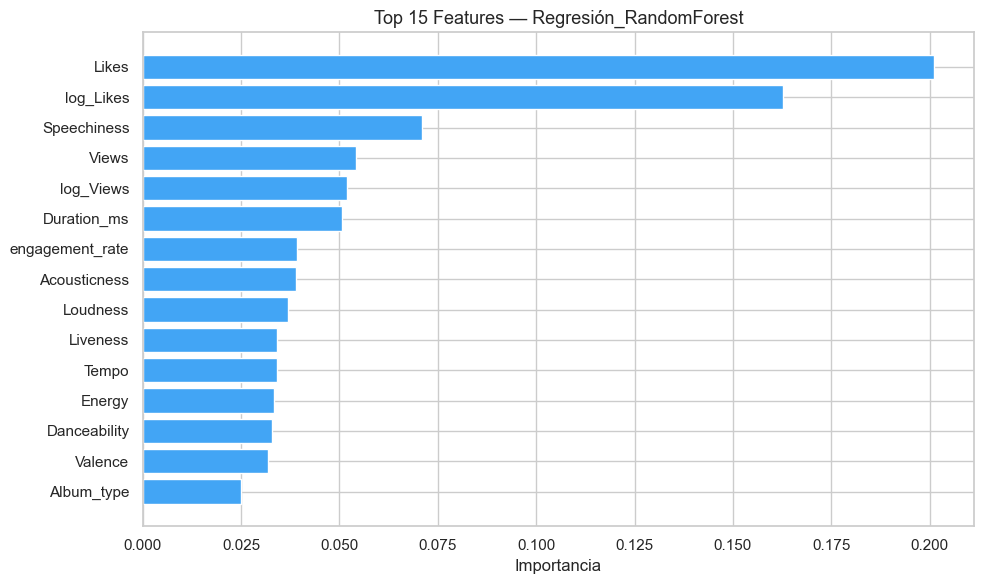

In [5]:
if hasattr(best_reg, "feature_importances_"):
    plot_feature_importance(best_reg, feature_names, title=f"Regresión_{best_reg_name}")

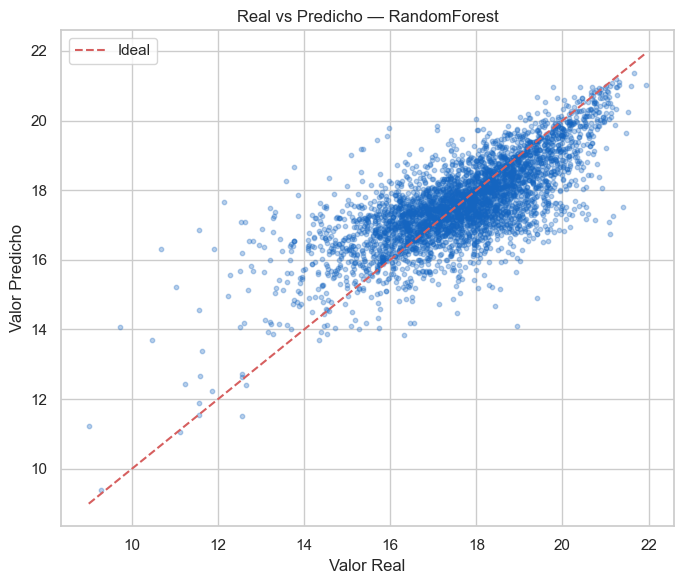

In [6]:

y_pred_r = best_reg.predict(X_test)
plot_actual_vs_predicted(y_test_r.values, y_pred_r, title=best_reg_name)

In [7]:
print("\n CLASIFICACIÓN — Predicción de canción viral")
clf_models = train_classification_models(X_train, y_train_c)


 CLASIFICACIÓN — Predicción de canción viral
LogisticRegression entrenado
RandomForest entrenado
XGBoost entrenado


In [8]:
clf_results = evaluate_classification(clf_models, X_test, y_test_c)
print("\n=== Resultados Clasificación ===")
print(clf_results.to_string(index=False))


=== Resultados Clasificación ===
            Modelo  Accuracy  F1-Score  ROC-AUC
      RandomForest    0.9646    0.6321   0.9109
           XGBoost    0.9619    0.6241   0.9168
LogisticRegression    0.9499    0.4401   0.8543


In [9]:
best_clf_name = clf_results.iloc[0]["Modelo"]
best_clf = clf_models[best_clf_name]
save_model(best_clf, f"best_classifier_{best_clf_name}")

Modelo guardado: models/best_classifier_RandomForest.pkl


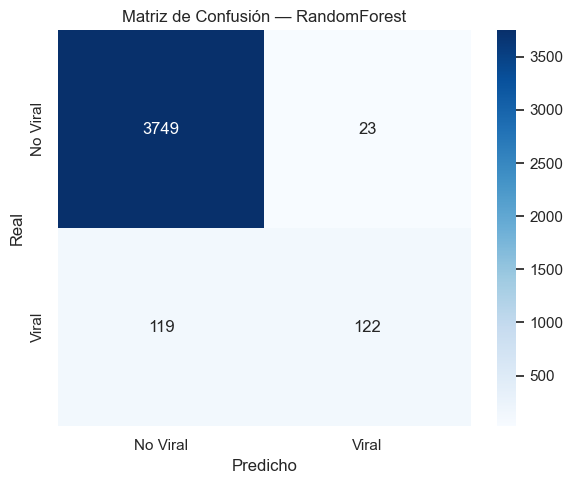

In [10]:
y_pred_c = best_clf.predict(X_test)
plot_confusion_matrix(y_test_c, y_pred_c, title=best_clf_name)

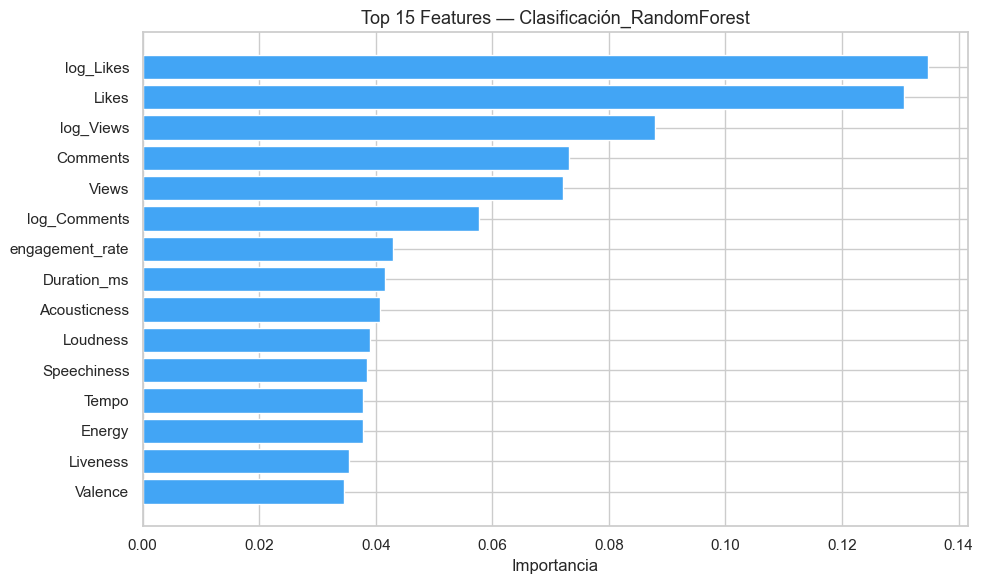

In [11]:
if hasattr(best_clf, "feature_importances_"):
    plot_feature_importance(best_clf, feature_names, title=f"Clasificación_{best_clf_name}")


CLUSTERING — Segmentación de canciones
  k=2 | Silhouette: 0.539
  k=3 | Silhouette: 0.545
  k=4 | Silhouette: 0.481
  k=5 | Silhouette: 0.487
  k=6 | Silhouette: 0.454
  k=7 | Silhouette: 0.445
  k=8 | Silhouette: 0.437


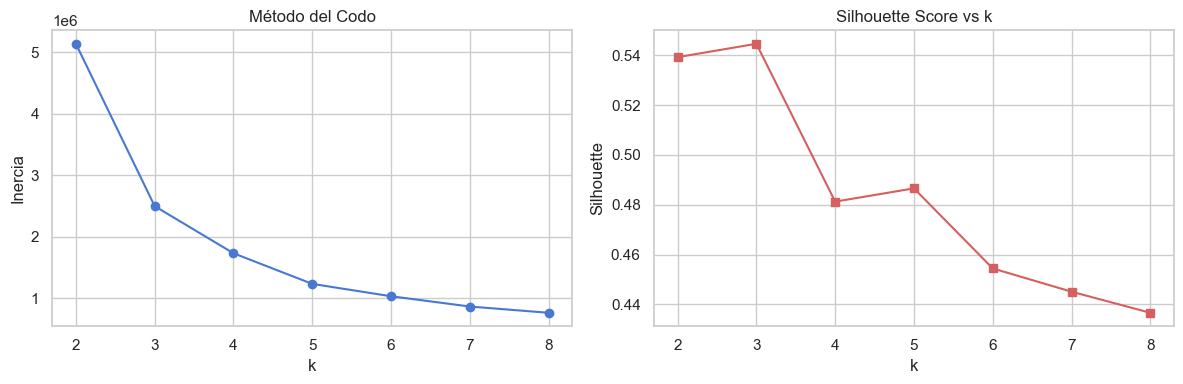

In [12]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

print("\nCLUSTERING — Segmentación de canciones")
audio_feats = ["Danceability","Energy","Valence","Loudness",
               "Acousticness","Speechiness","Instrumentalness","Tempo"]
X_cluster = X_train[[f for f in audio_feats if f in feature_names]]

# Elbow method
inertias = []
sil_scores = []
K_range = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_cluster)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_cluster, labels))
    print(f"  k={k} | Silhouette: {sil_scores[-1]:.3f}")

import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(K_range, inertias, "bo-")
axes[0].set_title("Método del Codo")
axes[0].set_xlabel("k"); axes[0].set_ylabel("Inercia")
axes[1].plot(K_range, sil_scores, "rs-")
axes[1].set_title("Silhouette Score vs k")
axes[1].set_xlabel("k"); axes[1].set_ylabel("Silhouette")
plt.tight_layout()
plt.savefig("../reports/figures/clustering_elbow.png", dpi=150)
plt.show()

In [13]:
best_k = K_range[np.argmax(sil_scores)]
km_best = KMeans(n_clusters=best_k, random_state=42, n_init=10)
clusters = km_best.fit_predict(X_cluster)
save_model(km_best, "kmeans_clusters")
print(f"\n Mejor k = {best_k} | Silhouette = {max(sil_scores):.3f}")

Modelo guardado: models/kmeans_clusters.pkl

 Mejor k = 3 | Silhouette = 0.545


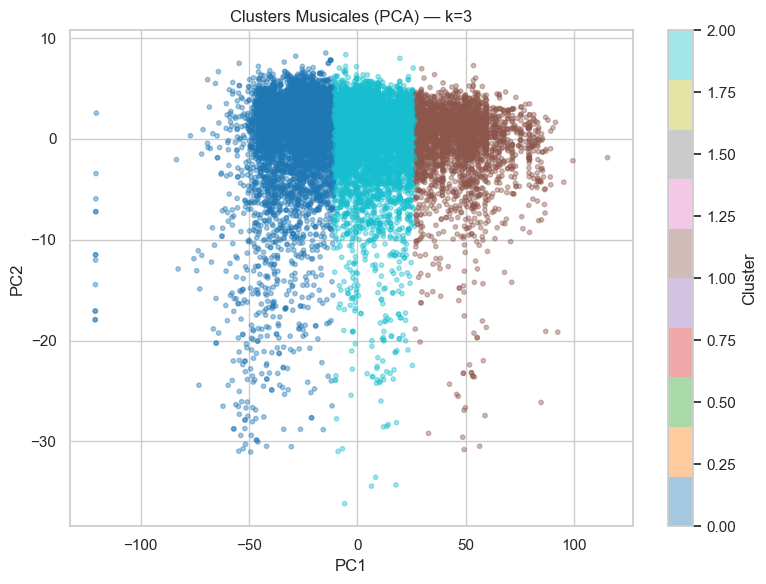

In [14]:

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_cluster)
fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters,
                     cmap="tab10", alpha=0.4, s=10)
plt.colorbar(scatter, ax=ax, label="Cluster")
ax.set_title(f"Clusters Musicales (PCA) — k={best_k}")
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
plt.tight_layout()
plt.savefig("../reports/figures/clusters_pca.png", dpi=150)
plt.show()